<a href="https://colab.research.google.com/github/KaiFish/DACSS-690C-Homework/blob/main/homework_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><img src="https://github.com/DACSS-CSSmeths/guidelines/blob/main/pics/small_logo_ccs_meths.jpg?raw=true" width="700"></center>







-------


# Homework 1
### Kai Barclay

<a target="_blank" href="https://colab.research.google.com/github/DACSS-CSSmeths-summer/spatial/blob/main/index.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Importing all Packages
Here, we import all packages and set the seed to 42 to ensure reproducability.

In [5]:
import geopandas as gpd
import pandas as pd
import esda # from pysal
from libpysal.graph import Graph
from numpy.random import seed
seed(42)

## The Map

We read in the map of Peru, and verify if it is projected.

In [9]:
LinkPeru="https://github.com/KaiFish/DACSS-690C-Homework/raw/main/PeruMaps.gpkg" #from my repo
peru=gpd.read_file(LinkPeru,layer='good_geom') # reading in the file
peru.crs.is_projected #is it projected?


False

It is not projected, so let's fix that.

In [10]:
peru=peru.to_crs(5387)

## Lima and LISA
### Queen Criterion
Now let's isolate Lima and produce our LISA map with the normalized neighborhood matrix using the queen criterion.

<Axes: >

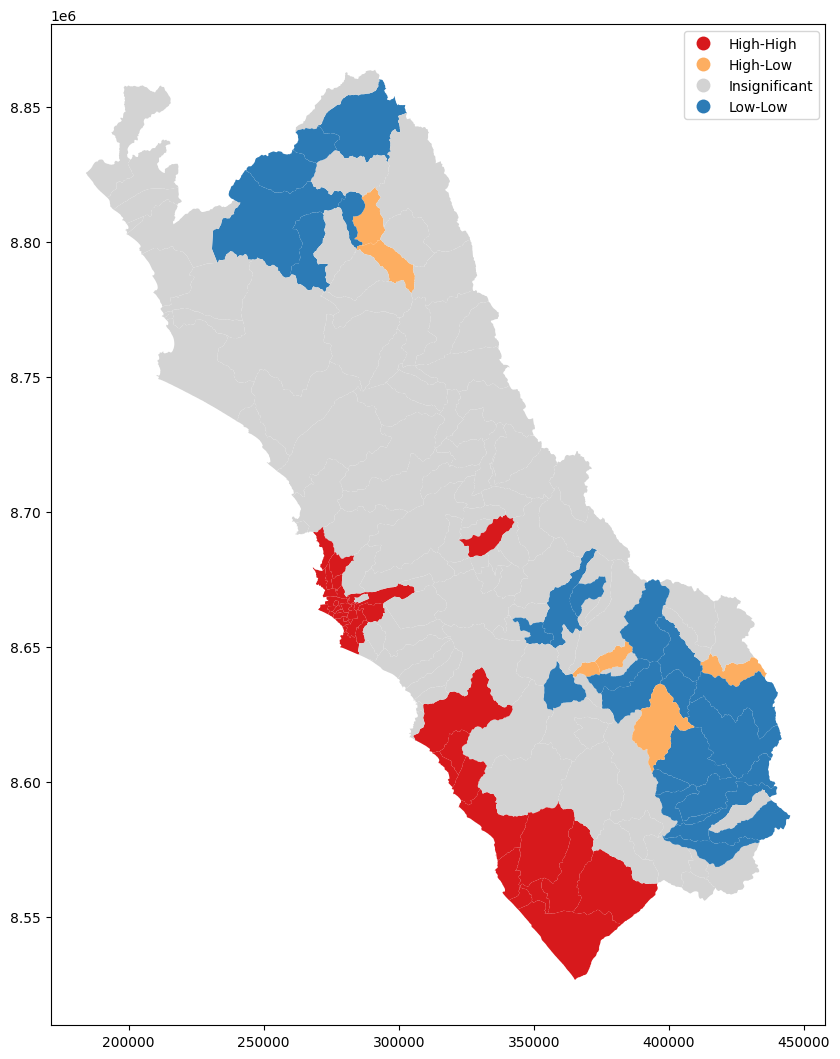

In [16]:
lima=peru[peru['DEPARTAMENTO']=='Lima'] #isolating Lima
lima_queen=Graph.build_contiguity(lima,rook=False) #create neighborhood matrix with queen criterion
lima_queen=lima_queen.transform("r") #normalize the matrix
lisa = esda.Moran_Local(lima['Educ_sec_comp2019_pct'], lima_queen) #compute LISA
lisa.plot(lima,crit_value=0.05,figsize=(10,13),legend=True) #display map

Now we can save the column as `lisa_queen`:

In [17]:
lima['lisa_queen'] = lisa.get_cluster_labels(crit_value=0.05)

/usr/local/lib/python3.12/dist-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


### K-Nearest Neighbors
We can now recompute the LISA map using K-Nearest Neighbors, with k=8.

<Axes: >

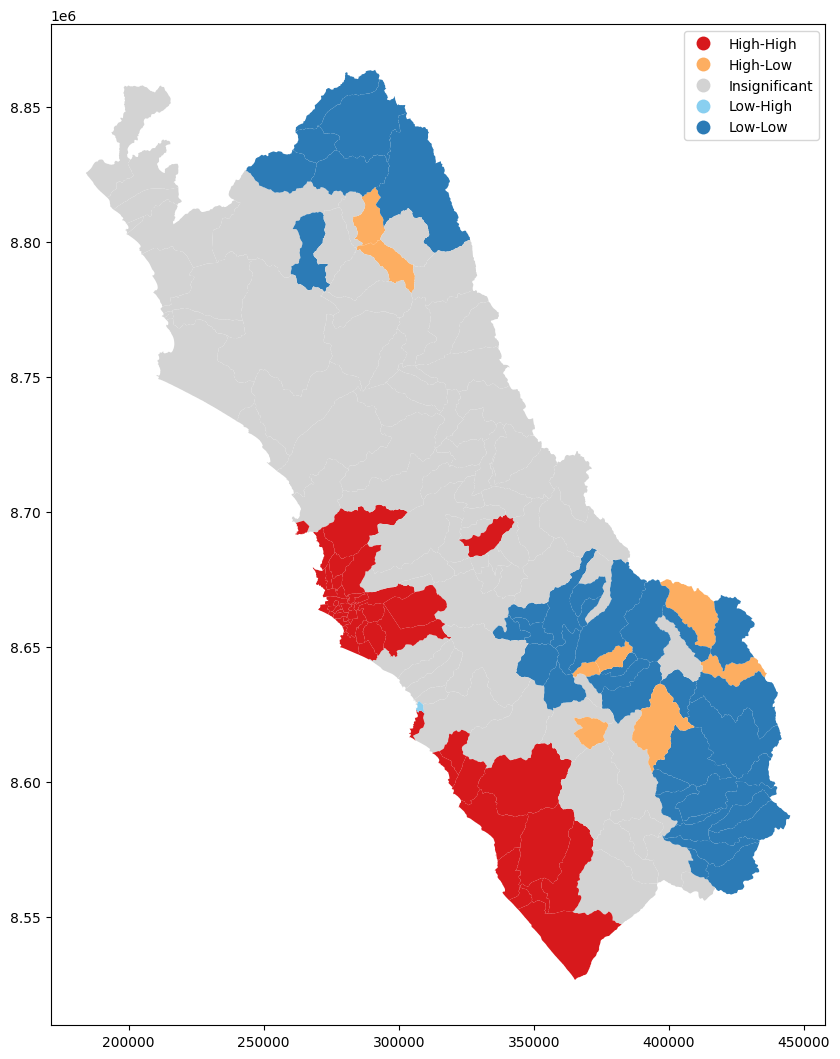

In [76]:
lima_ref=lima.representative_point() # get the points needed for calculating distances.
lima_knn8 = Graph.build_knn(lima_ref, k=8) # build knn8 graph
lisa = esda.Moran_Local(lima['Educ_sec_comp2019_pct'], lima_knn8) #compute LISA
lisa.plot(lima,crit_value=0.05,figsize=(10,13),legend=True) #display map

Now let's save the column as `lisa_knn8`:

In [77]:
lima['lisa_knn8'] = lisa.get_cluster_labels(crit_value=0.05)

### Report
First let us look at the value counts for `lisa_queen` and `lisa_knn8`.

In [80]:
lima['lisa_queen'].value_counts()

,count
lisa_queen,
Insignificant,102
High-High,39
Low-Low,24
High-Low,6


In [81]:
lima['lisa_knn8'].value_counts()

,count
lisa_knn8,
Insignificant,79
High-High,47
Low-Low,36
High-Low,8
Low-High,1


We can see both by the maps and the value counts that the 171 distritos of Lima are distributed differently based on our method. We can specifically check where the values of `lisa_queen` and `lisa_knn8` are not equal to gain farther insight:

In [92]:
lima_neq = lima.loc[lima['lisa_queen']!=lima['lisa_knn8']]
len(lima_neq)

33

So only 33 (approx 19%) of distritos are catagorized differently between methods. We can see which distritos are in this group with the code below.

In [96]:
lima_neq[['DISTRITO', 'lisa_queen', 'lisa_knn8']]

,DISTRITO,lisa_queen,lisa_knn8
54,AMBAR,Low-Low,Insignificant
224,CARABAYLLO,Insignificant,High-High
257,CAUJUL,Low-Low,Insignificant
329,CHILCA,High-High,Insignificant
390,CIENEGUILLA,Insignificant,High-High
396,COAYLLO,Insignificant,High-High
450,COPA,Insignificant,Low-Low
479,CUENCA,Insignificant,Low-Low
544,GORGOR,Insignificant,Low-Low
557,HONGOS,Insignificant,Low-Low


By visual inspection, we can see that `lisa_queen` is more likely to group distritos as insignificant compared to `lisa_knn8`.